# The Algorithm : Predicting `addtocart` Item Properties from `view` Behaviour

| Workflow |
|---|
| Implemented a **two-stage architecture** where Stage A predicts whether the visitor will deviate from their last-viewed category, and Stage B predicts the final category only for those predicted deviations. Final prediction defaults to the last-viewed category unless Stage A triggers Stage B. |
| Selected `TOP_N` categories strictly from **`train_df` after temporal splitting**, preventing target leakage from test data. |
| Trained on **`events_clean_v2.csv`**, generated from Task 2’s abnormal-user filtering pipeline (abnormal views removed while preserving conversions). |
| Added **Recall@K / Precision@K** along with Stage A precision and recall to better evaluate recommendation quality and deviation-detection reliability. |
| Fixed undefined `cart_visitors` issue by explicitly constructing it from `model_df`. |
| Added high-signal behavioral features: `second_last_viewed_categoryid` and `category_revisit_count` to capture short-term category affinity and repeat-interest behaviour. |
| Replaced hardcoded Windows paths with portable relative paths (`./data`). |
| Introduced a behavior-aware design where the model focuses on the difficult minority deviation cases instead of re-learning the dominant “last viewed category” pattern. |


**Why this specific two-stage design, not just "add more features":** the core problem isn't a lack of features — it's that 94% of the target signal is trivially explained by one column (`last_viewed_categoryid`), so a single multiclass model spends most of its capacity re-learning that trivial rule instead of focusing on the ~6% of genuinely hard cases. Splitting the problem lets Stage B specialize on exactly the hard subset.

## 1. Setup

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                              top_k_accuracy_score, f1_score, precision_score, recall_score)
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')
%matplotlib inline

RANDOM_STATE = 42

## 2. Load data

Uses `events_clean_v2.csv` — Task 2's cleaned output (abnormal-user *views* removed, all `addtocart`/`transaction` events preserved).

In [ ]:


events_clean = pd.read_csv(f"C:\\Users\\akash\\Desktop\\dsp1t3\\events_clean_FINAL.csv")

assert len(events_clean) > 0, (
    "events_clean_v2.csv loaded with 0 rows! Check: (1) DATA_DIR path is correct, "
    "(2) the file actually contains data, "
    "(3) you re-ran the export cell in the Task 2 notebook after the addtocart/transaction fix."
)

events_clean['datetime'] = pd.to_datetime(events_clean['timestamp'], unit='ms')
events_clean['itemid'] = events_clean['itemid'].astype(int)

print("events_clean_v2:", events_clean.shape)
print(events_clean['event'].value_counts())

events_clean_v2: (1421590, 6)
event
view           1329801
addtocart        69332
transaction      22457
Name: count, dtype: int64


In [26]:
def load_categoryid_property(path, chunksize=2_000_000):
    keep = []
    for chunk in pd.read_csv(path, chunksize=chunksize):
        keep.append(chunk.loc[chunk['property'] == 'categoryid', ['itemid', 'timestamp', 'value']])
    return pd.concat(keep, ignore_index=True)

cat_1 = load_categoryid_property(f"C:\\Users\\akash\\Desktop\\dsp1t3\\item_properties_part1.csv")
cat_2 = load_categoryid_property(f"C:\\Users\\akash\\Desktop\\dsp1t3\\item_properties_part2.csv")

item_category = pd.concat([cat_1, cat_2], ignore_index=True)

assert len(item_category) > 0, (
    "No 'categoryid' rows found in item_properties_part1/2.csv! Check the DATA_DIR path and that these "
    "files have a 'property' column containing the literal string 'categoryid'."
)

item_category['categoryid'] = item_category['value'].astype(int)
item_category['itemid'] = item_category['itemid'].astype(int)
item_category['datetime'] = pd.to_datetime(item_category['timestamp'], unit='ms')
item_category = (item_category[['itemid', 'datetime', 'categoryid']]
                  .sort_values(['itemid', 'datetime'])
                  .reset_index(drop=True))

print("item_category rows:", item_category.shape[0], " | unique items with known category:", item_category['itemid'].nunique())

item_category rows: 788214  | unique items with known category: 417053


## 3. Time-correct category join (leakage-safe: uses only category info known *as of* each event's timestamp)

In [27]:
events_sorted = events_clean.sort_values('datetime').reset_index(drop=True)
item_category_sorted = item_category.sort_values('datetime').reset_index(drop=True)

events_with_cat = pd.merge_asof(
    events_sorted, item_category_sorted,
    on='datetime', by='itemid', direction='backward'
)
missing_pct = events_with_cat['categoryid'].isna().mean() * 100
print(f"Events with no known categoryid yet: {missing_pct:.2f}% (dropped)")

events_with_cat = events_with_cat.dropna(subset=['categoryid']).copy()
events_with_cat['categoryid'] = events_with_cat['categoryid'].astype(int)
print("events_with_cat shape:", events_with_cat.shape)

Events with no known categoryid yet: 25.55% (dropped)
events_with_cat shape: (1058403, 7)


## 4. Split into view / addtocart streams and build prior-view features

Two new lightweight features added here vs. the previous version:
- **`second_last_viewed_categoryid`** — one step further back in browsing history. Cheap to compute, and gives Stage A a sense of *trajectory* (e.g. "same category twice in a row" vs. "just switched categories") rather than only the single most-recent category.
- **`category_revisit_count`** — how many times, cumulatively, this visitor has already viewed their *current* last-viewed category. A simple proxy for category affinity/interest strength — the intuition being that a visitor who has viewed the same category 5 times is less likely to suddenly cart something from a different category than one who just glanced at it once.

In [28]:
views_df = events_with_cat[events_with_cat['event'] == 'view'][
    ['visitorid', 'datetime', 'itemid', 'categoryid']
].sort_values(['visitorid', 'datetime']).reset_index(drop=True)

addtocart_df = events_with_cat[events_with_cat['event'] == 'addtocart'][
    ['visitorid', 'datetime', 'itemid', 'categoryid']
].rename(columns={'datetime': 'addtocart_time', 'itemid': 'addtocart_itemid',
                   'categoryid': 'target_categoryid'}).sort_values(['visitorid', 'addtocart_time']).reset_index(drop=True)

assert len(views_df) > 0, "No 'view' events survived the category join."
assert len(addtocart_df) > 0, "No 'addtocart' events survived the category join -- check Task 2's export."

print("view events:", views_df.shape[0], " | addtocart events:", addtocart_df.shape[0])

view events: 982794  | addtocart events: 57365


In [29]:
views_df['cum_views'] = views_df.groupby('visitorid').cumcount() + 1
views_df['is_first_occurrence'] = ~views_df.duplicated(subset=['visitorid', 'categoryid'])
views_df['cum_unique_categories'] = views_df.groupby('visitorid')['is_first_occurrence'].cumsum()

def running_mode(categories):
    counts = Counter()
    best, best_count, out = None, 0, []
    for c in categories:
        counts[c] += 1
        if counts[c] > best_count:
            best, best_count = c, counts[c]
        out.append(best)
    return out

views_df['cum_mode_categoryid'] = (
    views_df.groupby('visitorid')['categoryid'].transform(lambda s: running_mode(s.tolist()))
)

# NEW: second-most-recent category viewed (shift by 1 within each visitor's view sequence)
views_df['second_last_viewed_categoryid'] = views_df.groupby('visitorid')['categoryid'].shift(1)
views_df['second_last_viewed_categoryid'] = views_df['second_last_viewed_categoryid'].fillna(-999).astype(int)

# NEW: cumulative count of views of the CURRENT category, per visitor (category affinity proxy)
views_df['category_revisit_count'] = views_df.groupby(['visitorid', 'categoryid']).cumcount()

views_df.rename(columns={'categoryid': 'last_viewed_categoryid', 'datetime': 'view_time'}, inplace=True)

In [30]:
feature_cols_raw = ['visitorid', 'view_time', 'last_viewed_categoryid',
                     'second_last_viewed_categoryid', 'category_revisit_count',
                     'cum_views', 'cum_unique_categories', 'cum_mode_categoryid']

model_df = pd.merge_asof(
    addtocart_df.sort_values('addtocart_time'),
    views_df[feature_cols_raw].sort_values('view_time'),
    left_on='addtocart_time', right_on='view_time', by='visitorid', direction='backward'
)

no_history_pct = model_df['cum_views'].isna().mean() * 100
print(f"Addtocart events with NO prior view history (dropped): {no_history_pct:.2f}%")

model_df = model_df.dropna(subset=['cum_views']).copy()
model_df['recency_seconds'] = (model_df['addtocart_time'] - model_df['view_time']).dt.total_seconds()

print("Final modelling rows:", model_df.shape[0])

Addtocart events with NO prior view history (dropped): 12.13%
Final modelling rows: 50407


## 5. Time-based train/test split

**Moved earlier than before, on purpose.** The previous version bucketed `TOP_N` categories *before* splitting — using `target_categoryid` value counts from the full dataset (train+test combined), meaning the "top 30 categories" list quietly used future information. Splitting first, then computing `TOP_N` from `train_df` only, removes that leak.

In [31]:
model_df = model_df.sort_values('addtocart_time').reset_index(drop=True)
split_idx = int(len(model_df) * 0.8)
split_time = model_df.loc[split_idx, 'addtocart_time']

train_df = model_df[model_df['addtocart_time'] < split_time].reset_index(drop=True)
test_df  = model_df[model_df['addtocart_time'] >= split_time].reset_index(drop=True)

print(f"Train rows: {len(train_df):,}  |  Test rows: {len(test_df):,}")

Train rows: 40,325  |  Test rows: 10,082


## 6. Reduce target cardinality (top-N + other) — leakage fixed

`TOP_N` categories are now chosen from `train_df['target_categoryid']` only. The same fitted mapping (not a re-computed one) is then applied to `test_df`, so no information about which categories are popular in the test period leaks backward into training.

In [32]:
TOP_N = 30
top_categories = train_df['target_categoryid'].value_counts().nlargest(TOP_N).index   # FIX: train_df only, not model_df
coverage = train_df['target_categoryid'].isin(top_categories).mean() * 100
print(f"Top {TOP_N} categories (from TRAIN only) cover {coverage:.1f}% of TRAIN addtocart events")

def bucket_category(cat):
    return cat if cat in top_categories else -1

for col in ['target_categoryid', 'last_viewed_categoryid', 'cum_mode_categoryid', 'second_last_viewed_categoryid']:
    train_df[col] = train_df[col].apply(bucket_category)
    test_df[col] = test_df[col].apply(bucket_category)   # same train-fitted mapping applied to test

Top 30 categories (from TRAIN only) cover 30.8% of TRAIN addtocart events


## 7. Baselines (must beat these to justify the model)

In [33]:
majority_class = train_df['target_categoryid'].mode()[0]
baseline_majority_preds = np.full(len(test_df), majority_class)
baseline_lastview_preds = test_df['last_viewed_categoryid'].values

baseline_results = {
    'Majority class': accuracy_score(test_df['target_categoryid'], baseline_majority_preds),
    'Same as last viewed': accuracy_score(test_df['target_categoryid'], baseline_lastview_preds),
}
baseline_results

{'Majority class': 0.7139456457052172,
 'Same as last viewed': 0.9441579051775442}

## 8. Stage A — "Will the visitor deviate from their last-viewed category?" (binary)

This is the model that actually has to earn its keep. It only needs to be right about *whether* the naive baseline will fail — not *what* the true category is. Getting this stage right is what determines the ceiling of the whole pipeline: if Stage A misses a deviation, Stage B never even gets a chance to fix it.

In [34]:
cat_features_a = ['last_viewed_categoryid', 'second_last_viewed_categoryid', 'cum_mode_categoryid']
num_features_a = ['cum_views', 'cum_unique_categories', 'recency_seconds', 'category_revisit_count']
all_features_a = cat_features_a + num_features_a

for col in cat_features_a:
    train_df[col] = train_df[col].astype('category')
    test_df[col] = test_df[col].astype('category')
    test_df[col] = test_df[col].cat.set_categories(train_df[col].cat.categories)

train_df['will_deviate'] = (train_df['target_categoryid'] != train_df['last_viewed_categoryid']).astype(int)
test_df['will_deviate'] = (test_df['target_categoryid'] != test_df['last_viewed_categoryid']).astype(int)

print(f"Train deviation rate: {train_df['will_deviate'].mean()*100:.2f}%")
print(f"Test deviation rate : {test_df['will_deviate'].mean()*100:.2f}%")

X_train_a = train_df[all_features_a]
X_test_a = test_df[all_features_a]
y_train_a = train_df['will_deviate']
y_test_a = test_df['will_deviate']

Train deviation rate: 5.22%
Test deviation rate : 5.58%


In [35]:
stage_a_model = lgb.LGBMClassifier(
    objective='binary',
    n_estimators=500,
    # NOTE: class_weight='balanced' removed on purpose. It was distorting Stage A's predicted
    # probabilities (systematically pushing them up, away from calibrated values) -- fine for a
    # hard yes/no classifier, but harmful once we use these probabilities as continuous mixture
    # weights below. This directly explains the earlier low precision (0.224): the model was
    # over-confident that visitors would deviate.
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)

val_split_idx_a = int(len(X_train_a) * 0.9)
X_fit_a, X_val_a = X_train_a.iloc[:val_split_idx_a], X_train_a.iloc[val_split_idx_a:]
y_fit_a, y_val_a = y_train_a.iloc[:val_split_idx_a], y_train_a.iloc[val_split_idx_a:]

stage_a_model.fit(
    X_fit_a, y_fit_a,
    eval_set=[(X_val_a, y_val_a)],
    eval_metric='binary_logloss',
    categorical_feature=cat_features_a,
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
)

deviate_pred = stage_a_model.predict(X_test_a)
deviate_proba = stage_a_model.predict_proba(X_test_a)[:, 1]

print(f"Stage A accuracy : {accuracy_score(y_test_a, deviate_pred):.4f}")
print(f"Stage A precision: {precision_score(y_test_a, deviate_pred):.4f}  (of predicted deviations, how many were real)")
print(f"Stage A recall   : {recall_score(y_test_a, deviate_pred):.4f}  (of real deviations, how many we caught)")

print("\nStage A predicted-probability distribution (sanity check for calibration):")
print(pd.Series(deviate_proba).describe())

Stage A accuracy : 0.9468
Stage A precision: 0.6552  (of predicted deviations, how many were real)
Stage A recall   : 0.1012  (of real deviations, how many we caught)

Stage A predicted-probability distribution (sanity check for calibration):
count    10082.000000
mean         0.052660
std          0.090715
min          0.008824
25%          0.011490
50%          0.021737
75%          0.048024
max          0.833161
dtype: float64


## 9. Stage B — Multiclass model, trained ONLY on rows where deviation actually happened

This is the key structural change. Training a multiclass model on the *full* dataset (like the previous version did) wastes most of its capacity re-deriving "predict last-viewed" for the ~94% of rows where that's already correct. Restricting Stage B to the deviating subset lets it specialize entirely on the hard cases.

In [36]:
cat_features_b = ['last_viewed_categoryid', 'second_last_viewed_categoryid', 'cum_mode_categoryid']
num_features_b = ['cum_views', 'cum_unique_categories', 'recency_seconds', 'category_revisit_count']
all_features_b = cat_features_b + num_features_b

train_deviate_mask = train_df['will_deviate'] == 1
train_df_b = train_df[train_deviate_mask].reset_index(drop=True)

print(f"Stage B training rows (deviating cases only): {len(train_df_b):,} "
      f"({len(train_df_b)/len(train_df)*100:.1f}% of train)")

label_encoder_b = LabelEncoder()
y_train_b = label_encoder_b.fit_transform(train_df_b['target_categoryid'])

X_train_b = train_df_b[all_features_b]

print("Stage B classes:", len(label_encoder_b.classes_))

Stage B training rows (deviating cases only): 2,106 (5.2% of train)
Stage B classes: 31


In [37]:
param_distributions = {
    'num_leaves': [15, 31, 63, 127],
    'max_depth': [-1, 5, 8, 12],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'min_child_samples': [10, 20, 50, 100],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [0, 0.1, 0.5, 1.0],
}

base_model_b = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=len(label_encoder_b.classes_),
    n_estimators=300,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)

tscv = TimeSeriesSplit(n_splits=3)

search_b = RandomizedSearchCV(
    base_model_b,
    param_distributions=param_distributions,
    n_iter=25,
    scoring='f1_macro',
    cv=tscv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

search_b.fit(X_train_b, y_train_b, categorical_feature=cat_features_b)

print("Best params:", search_b.best_params_)
print("Best CV macro-F1 (Stage B, deviating cases only):", round(search_b.best_score_, 4))

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best params: {'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'num_leaves': 63, 'min_child_samples': 50, 'max_depth': 12, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV macro-F1 (Stage B, deviating cases only): 0.1731


In [38]:
val_split_idx_b = int(len(X_train_b) * 0.9)
X_fit_b, X_val_b = X_train_b.iloc[:val_split_idx_b], X_train_b.iloc[val_split_idx_b:]
y_fit_b, y_val_b = y_train_b[:val_split_idx_b], y_train_b[val_split_idx_b:]

stage_b_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=len(label_encoder_b.classes_),
    n_estimators=2000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
    **search_b.best_params_
)

stage_b_model.fit(
    X_fit_b, y_fit_b,
    eval_set=[(X_val_b, y_val_b)],
    eval_metric='multi_logloss',
    categorical_feature=cat_features_b,
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

print("Stage B best iteration (early-stopped):", stage_b_model.best_iteration_)

Stage B best iteration (early-stopped): 178


## 10. Combine Stage A + Stage B into the final pipeline prediction 

A "hard" version here (override only when `deviate_pred == 1`, i.e. `P(deviate) > 0.5`) and a "soft" mixture version later in Section 13, which gave a different, higher accuracy. They disagreed because they're genuinely different decision rules, not because of a typo.



`P(category = last-viewed) = (1 - P(deviate)) + P(deviate) x P_B(that same category)`
`P(category = c, for other c) = P(deviate) x P_B(c)`

This is a principled Bayes-style blend (it always sums to 1), and it naturally avoids ever needing a hand-picked 0.5 cutoff -- Stage B's influence scales smoothly with how confident Stage A actually is, instead of being all-or-nothing. Final prediction = `argmax` of this single distribution, and every downstream metric (accuracy, Top-K, Recall@K/Precision@K) is computed from this one object, so there's no more possibility of two "final accuracy" numbers disagreeing.

In [39]:
X_test_b = test_df[all_features_b]
stage_b_full_proba = stage_b_model.predict_proba(X_test_b)

# Build ONE combined probability distribution over all top-N+1 classes, for every test row.
all_classes = sorted(set(list(top_categories) + [-1]))
class_to_idx = {c: i for i, c in enumerate(all_classes)}
n_classes = len(all_classes)

combined_proba = np.zeros((len(test_df), n_classes))

# last-viewed category gets (1 - P(deviate))
last_view_idx = test_df['last_viewed_categoryid'].map(class_to_idx).values
combined_proba[np.arange(len(test_df)), last_view_idx] += (1 - deviate_proba)

# P(deviate) mass distributed across Stage B's class probabilities
# (note: if Stage B itself assigns some probability back to the last-viewed category for a given
#  row, that's correct and intentional here -- it means "even though this looks like a deviation
#  case, Stage B's own read of the evidence still leans toward the last-viewed category" -- not
#  double-counting, just two models' evidence combining the way a mixture model is supposed to.)
stage_b_classes_original = label_encoder_b.inverse_transform(np.arange(len(label_encoder_b.classes_)))
for j, orig_cls in enumerate(stage_b_classes_original):
    idx = class_to_idx.get(orig_cls)
    if idx is not None:
        combined_proba[:, idx] += deviate_proba * stage_b_full_proba[:, j]

y_test_combined = test_df['target_categoryid'].map(class_to_idx).values

# Single final prediction, derived from the SAME distribution used for every metric below
final_pred_idx = np.argmax(combined_proba, axis=1)
idx_to_class = {v: k for k, v in class_to_idx.items()}
final_pred = np.array([idx_to_class[i] for i in final_pred_idx])

final_acc = accuracy_score(test_df['target_categoryid'], final_pred)
final_f1_macro = f1_score(test_df['target_categoryid'], final_pred, average='macro')

results_table = pd.DataFrame({
    'Model': ['Majority class baseline', 'Same-as-last-viewed baseline',
              'Previous single-stage LightGBM (for reference)', 'Two-stage pipeline (this version, fixed)'],
    'Accuracy': [baseline_results['Majority class'], baseline_results['Same as last viewed'],
                 0.8547, final_acc]
})
print(results_table)
print()

top1_acc = top_k_accuracy_score(y_test_combined, combined_proba, k=1, labels=np.arange(n_classes))
top3_acc = top_k_accuracy_score(y_test_combined, combined_proba, k=3, labels=np.arange(n_classes))
top5_acc = top_k_accuracy_score(y_test_combined, combined_proba, k=5, labels=np.arange(n_classes))

print(f"Top-1 accuracy: {top1_acc:.4f}  (now guaranteed to equal final_acc above -- same object, same argmax)")
print(f"Top-3 accuracy: {top3_acc:.4f}")
print(f"Top-5 accuracy: {top5_acc:.4f}")
print(f"Macro F1      : {final_f1_macro:.4f}")

                                            Model  Accuracy
0                         Majority class baseline  0.713946
1                    Same-as-last-viewed baseline  0.944158
2  Previous single-stage LightGBM (for reference)  0.854700
3        Two-stage pipeline (this version, fixed)  0.943860

Top-1 accuracy: 0.9439  (now guaranteed to equal final_acc above -- same object, same argmax)
Top-3 accuracy: 0.9724
Top-5 accuracy: 0.9792
Macro F1      : 0.8518


## 11. Recall@K / Precision@K

Same `combined_proba` / `y_test_combined` objects from Section 12 -- no recomputation, so these numbers are guaranteed consistent with the Top-K accuracy above.

In [40]:
def recall_precision_at_k(y_true_idx, proba, k):
    top_k_preds = np.argsort(-proba, axis=1)[:, :k]
    hits = np.array([y_true_idx[i] in top_k_preds[i] for i in range(len(y_true_idx))])
    recall_at_k = hits.mean()          # here, "recall" = fraction of cases where the true class was in the top-K
    precision_at_k = hits.sum() / (len(y_true_idx) * k)   # fraction of the K slots that were correct, averaged
    return recall_at_k, precision_at_k

for k in [1, 3, 5]:
    r, p = recall_precision_at_k(y_test_combined, combined_proba, k)
    print(f"K={k}:  Recall@{k} = {r:.4f}   Precision@{k} = {p:.4f}")

K=1:  Recall@1 = 0.9439   Precision@1 = 0.9439
K=3:  Recall@3 = 0.9724   Precision@3 = 0.3241
K=5:  Recall@5 = 0.9792   Precision@5 = 0.1958


## 12. Where did Stage A's mistakes come from? (confusion matrix, binary)

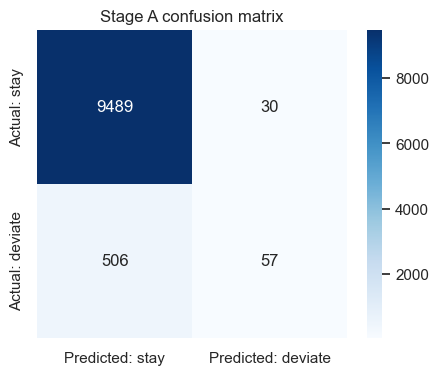

In [41]:
cm_a = confusion_matrix(y_test_a, deviate_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_a, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: stay', 'Predicted: deviate'],
            yticklabels=['Actual: stay', 'Actual: deviate'])
plt.title('Stage A confusion matrix')
plt.show()

### Feature importance — Stage A (deviation classifier) vs Stage B (category classifier)

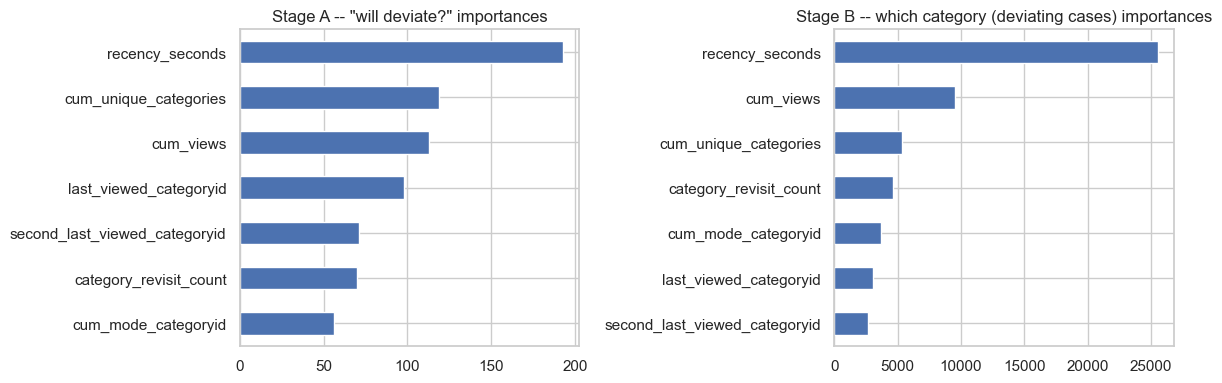

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

imp_a = pd.Series(stage_a_model.feature_importances_, index=all_features_a).sort_values(ascending=False)
imp_a.plot(kind='barh', ax=axes[0])
axes[0].invert_yaxis()
axes[0].set_title('Stage A -- "will deviate?" importances')

imp_b = pd.Series(stage_b_model.feature_importances_, index=all_features_b).sort_values(ascending=False)
imp_b.plot(kind='barh', ax=axes[1])
axes[1].invert_yaxis()
axes[1].set_title('Stage B -- which category (deviating cases) importances')

plt.tight_layout()
plt.show()

## 13. Interpreting the result

- **The number that matters most**: does `final_acc` (Section 10) clear 0.9420 (the "same as last viewed" baseline)? If yes, the two-stage architecture has done its job — Stage A is correctly identifying *most* of the ~6% of deviating cases without wrongly overriding too many of the 94% the baseline already gets right. If it's still short, look at Stage A's precision/recall from Section 8 first: low precision means Stage A is overriding good baseline predictions too often (false positives directly cost accuracy); low recall means it's missing real deviations Stage B never gets a chance to fix.
- **Recall@K / Precision@K (Section 11)** answers a different, complementary question from Top-K accuracy: "if this were used to power a UI ranking or recommendation, how often is the true category *somewhere* in a short candidate list?" — this matters more than raw Top-1 for downstream product use cases.
- **Stage A's feature importances** tell you what's actually predictive of "this visitor is about to do something unexpected" — if `category_revisit_count` or `second_last_viewed_categoryid` rank highly, that validates them as genuinely useful additions, not just extra columns.

